# 17 · 토스+메인 신규 기기 후속 라벨 EDA

**한 줄 답:** 메인·웹까지 합치면 표본은 95대로 늘지만, 후속 행동 양성 12대·새 영역 양성 9대라 아직 모델 학습보다는 라벨 후보 감사 단계다.

**이번 게이트:** A/B 효과는 보지 않는다. 베타 테스터 표식(`beta_A/B`) 기기만 제외하고, 2026-09-04~09-11에 처음 관측된 전체 신규 기기의 첫 10분 행동과 이후 24시간 행동 후보를 본다.

**사전 기준:** 표본이 14~16번보다 커졌는지, 경계 위반이 0인지, 토스 관측/메인·웹만 채널별 양성 수가 모델링 가능한지 문서화하면 통과. 모델 학습·A/B 비교·인과 해석은 하지 않는다.

## 1. 정의

- 원천은 BigQuery GA4 일별 export 2026-07-27~09-12이며, **최초 관측일**이 2026-09-04~09-11인 기기만 남긴다. 라벨 창 24시간을 보려면 9/12 후반 신규 기기는 제외된다.
- `토스 관측`은 첫 10분 피처 창 안에 `platform='toss'` 이벤트가 있는 기기다. 나머지는 `메인·웹만`이다.
- 베타 테스터 표식으로 쓰던 `beta_A/B`가 한 번이라도 찍힌 기기는 제외한다. A/B arm별 차이는 보지 않는다.
- 첫 10분은 피처 창, 10분 이후~24시간은 라벨 창이다. 자동 이벤트와 로그인/장부 이벤트는 의도적 행동에서 제외한다.

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import bq, report as R

R.setup()
SQL = ROOT / 'ml/sql/g3_all_channel_later_target_candidates.sql'
OUT = ROOT / 'ml/reports/g3_all_channel_later_targets_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

def wilson(k, n, z=1.96):
    if n == 0:
        return 0, 0
    p = k / n
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5) / den
    return center - half, center + half


## 2. 실행 SQL

In [2]:
display(Markdown('```sql\n' + SQL.read_text(encoding='utf-8') + '\n```'))
d = bq.read_sql_file(str(SQL))
d.to_csv(OUT / 'all_channel_later_target_candidates.csv', index=False)

assert len(d) == 95
assert int(d.later_active.sum()) == 12
assert int(d.later_new_area.sum()) == 9
assert int(d.feature_boundary_violations.sum()) == 0
assert int(d.label_boundary_violations.sum()) == 0
assert d.device_label.is_unique
display(d.head(10))


```sql
-- G3 all-channel later-target candidate audit, NOT a model and NOT an A/B read.
-- Cohort: GA4 devices whose first observed event in the full export history is
-- 2026-09-04..2026-09-11 KST, with a complete 24h label window available.
-- Exclude marked beta tester devices (ab_variant beta_A/beta_B). Do not segment
-- or draw conclusions by A/B arm.
-- Channel segment: whether Toss platform appears in the first 10m feature window.
-- Feature window: [first_ts, +10m). Candidate labels: [+10m, +24h).
-- Raw GA4 device IDs stay inside the query; output uses D001 labels.
WITH actions AS (
  SELECT action_name, area FROM UNNEST([
    STRUCT('chop_tree' AS action_name, 'nature' AS area),
    ('first_chop', 'nature'),
    ('plant_seed', 'nature'),
    ('water_crop', 'nature'),
    ('harvest_crop', 'nature'),
    ('forage_pick', 'nature'),
    ('mine_ore', 'nature'),
    ('fishing_cast', 'fishing_sea'),
    ('fishing_catch', 'fishing_sea'),
    ('fishing_miss', 'fishing_sea'),
    ('sea_cast', 'fishing_sea'),
    ('sea_catch', 'fishing_sea'),
    ('boat_start', 'fishing_sea'),
    ('npc_talk', 'quest_social'),
    ('quest_accept', 'quest_social'),
    ('quest_complete', 'quest_social'),
    ('gift_give', 'quest_social'),
    ('shop_sell', 'craft_home'),
    ('shop_buy', 'craft_home'),
    ('craft_item', 'craft_home'),
    ('place_decor', 'craft_home'),
    ('house_complete', 'craft_home'),
    ('house_expand', 'craft_home'),
    ('cooking_start', 'craft_home'),
    ('carve_start', 'craft_home'),
    ('mist_purify_start', 'advanced'),
    ('firefly_swing', 'advanced'),
    ('coop_build', 'advanced'),
    ('coop_feed', 'advanced'),
    ('coop_collect', 'advanced'),
    ('cafe_serve', 'advanced'),
    ('photo_capture', 'advanced'),
    ('dex_open', 'advanced'),
    ('album_open', 'advanced'),
    ('leaderboard_open', 'advanced')
  ])
),
base AS (
  SELECT
    user_pseudo_id,
    TIMESTAMP_MICROS(event_timestamp) AS ts,
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
    event_name,
    device.category AS device,
    geo.country AS country,
    traffic_source.source AS acquisition_source,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'platform' LIMIT 1) AS platform,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'method' LIMIT 1) AS login_method,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'result' LIMIT 1) AS connect_result,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND _TABLE_SUFFIX BETWEEN '20260727' AND '20260912'
    AND user_pseudo_id IS NOT NULL
),
first_seen AS (
  SELECT
    user_pseudo_id,
    MIN(ts) AS first_ts,
    MIN(day) AS first_day,
    LOGICAL_OR(REGEXP_CONTAINS(COALESCE(ab_variant, ''), r'^beta_[AB]$')) AS beta_marked
  FROM base
  GROUP BY 1
),
eligible AS (
  SELECT *
  FROM first_seen
  WHERE NOT beta_marked
    AND first_day BETWEEN DATE '2026-09-04' AND DATE '2026-09-11'
    AND first_ts < TIMESTAMP_SUB(TIMESTAMP('2026-09-13 00:00:00', 'Asia/Seoul'), INTERVAL 24 HOUR)
),
windowed AS (
  SELECT
    b.*,
    e.first_ts,
    e.first_day,
    a.area,
    CASE
      WHEN b.ts >= e.first_ts
       AND b.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE) THEN 'feature'
      WHEN b.ts >= TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE)
       AND b.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 24 HOUR) THEN 'label'
      ELSE 'outside'
    END AS window_name
  FROM base b
  JOIN eligible e USING (user_pseudo_id)
  LEFT JOIN actions a ON b.event_name = a.action_name
  WHERE b.ts >= e.first_ts
    AND b.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 24 HOUR)
),
device AS (
  SELECT
    user_pseudo_id,
    first_ts,
    first_day,
    ARRAY_AGG(STRUCT(
      COALESCE(device, '(unknown)') AS device,
      CASE
        WHEN country = 'South Korea' THEN 'South Korea'
        WHEN country = 'United States' THEN 'United States'
        WHEN country IS NULL THEN '(unknown)'
        ELSE 'Other'
      END AS country_group,
      COALESCE(acquisition_source, '(direct)') AS acquisition_source
    ) ORDER BY ts LIMIT 1)[OFFSET(0)] AS profile,
    LOGICAL_OR(window_name = 'feature' AND platform = 'toss') AS toss_in_feature_window,
    COUNTIF(window_name = 'feature') AS early_tracked_events,
    COUNTIF(window_name = 'feature' AND area IS NOT NULL) AS early_actions,
    COUNT(DISTINCT IF(window_name = 'feature' AND area IS NOT NULL, event_name, NULL)) AS early_action_kinds,
    COUNT(DISTINCT IF(window_name = 'feature' AND area IS NOT NULL, area, NULL)) AS early_area_count,
    COUNTIF(window_name = 'feature' AND area = 'nature') AS early_nature_events,
    COUNTIF(window_name = 'feature' AND area = 'fishing_sea') AS early_fishing_sea_events,
    COUNTIF(window_name = 'feature' AND area = 'quest_social') AS early_quest_social_events,
    COUNTIF(window_name = 'feature' AND area = 'craft_home') AS early_craft_home_events,
    COUNTIF(window_name = 'feature' AND area = 'advanced') AS early_advanced_events,
    COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'fail') AS early_connect_fail,
    COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'ok') AS early_connect_ok,
    COUNTIF(window_name = 'feature' AND event_name = 'login' AND login_method = 'toss') AS early_toss_login,
    COUNTIF(window_name = 'feature' AND event_name = 'login_screen') AS early_login_screen,
    COUNTIF(window_name = 'label' AND area IS NOT NULL) AS later_actions,
    COUNT(DISTINCT IF(window_name = 'label' AND area IS NOT NULL, event_name, NULL)) AS later_action_kinds,
    COUNT(DISTINCT IF(window_name = 'label' AND area IS NOT NULL, area, NULL)) AS later_area_count,
    COUNTIF(window_name = 'label' AND area = 'nature') AS later_nature_events,
    COUNTIF(window_name = 'label' AND area = 'fishing_sea') AS later_fishing_sea_events,
    COUNTIF(window_name = 'label' AND area = 'quest_social') AS later_quest_social_events,
    COUNTIF(window_name = 'label' AND area = 'craft_home') AS later_craft_home_events,
    COUNTIF(window_name = 'label' AND area = 'advanced') AS later_advanced_events,
    COUNTIF(window_name = 'label' AND area = 'nature' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'nature'
    )) AS later_new_nature_events,
    COUNTIF(window_name = 'label' AND area = 'fishing_sea' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'fishing_sea'
    )) AS later_new_fishing_sea_events,
    COUNTIF(window_name = 'label' AND area = 'quest_social' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'quest_social'
    )) AS later_new_quest_social_events,
    COUNTIF(window_name = 'label' AND area = 'craft_home' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'craft_home'
    )) AS later_new_craft_home_events,
    COUNTIF(window_name = 'label' AND area = 'advanced' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'advanced'
    )) AS later_new_advanced_events,
    MAX(IF(window_name = 'feature' AND area IS NOT NULL, ts, NULL)) AS last_feature_action_ts,
    MIN(IF(window_name = 'label' AND area IS NOT NULL, ts, NULL)) AS first_label_action_ts
  FROM windowed
  GROUP BY 1, 2, 3
)
SELECT
  FORMAT('D%03d', ROW_NUMBER() OVER (ORDER BY FARM_FINGERPRINT(user_pseudo_id))) AS device_label,
  first_day,
  IF(toss_in_feature_window, '토스 관측', '메인·웹만') AS channel_segment,
  profile.device AS device,
  profile.country_group AS country_group,
  profile.acquisition_source AS acquisition_source,
  early_tracked_events,
  early_actions,
  early_action_kinds,
  early_area_count,
  early_nature_events,
  early_fishing_sea_events,
  early_quest_social_events,
  early_craft_home_events,
  early_advanced_events,
  early_connect_fail,
  early_connect_ok,
  early_toss_login,
  early_login_screen,
  later_actions,
  later_action_kinds,
  later_area_count,
  later_nature_events,
  later_fishing_sea_events,
  later_quest_social_events,
  later_craft_home_events,
  later_advanced_events,
  later_new_nature_events,
  later_new_fishing_sea_events,
  later_new_quest_social_events,
  later_new_craft_home_events,
  later_new_advanced_events,
  later_actions > 0 AS later_active,
  (
    later_new_nature_events
    + later_new_fishing_sea_events
    + later_new_quest_social_events
    + later_new_craft_home_events
    + later_new_advanced_events
  ) > 0 AS later_new_area,
  later_quest_social_events > 0 AS later_quest_social,
  later_fishing_sea_events > 0 AS later_fishing_sea,
  later_nature_events > 0 AS later_nature,
  CASE WHEN early_actions = 0 THEN '0회'
       WHEN early_actions BETWEEN 1 AND 5 THEN '1~5회'
       ELSE '6회 이상' END AS early_action_segment,
  CASE WHEN early_area_count = 0 THEN '0개'
       WHEN early_area_count = 1 THEN '1개'
       ELSE '2개 이상' END AS early_area_segment,
  CASE
    WHEN early_connect_fail > 0 THEN '토스 연결 실패 기록'
    WHEN early_connect_ok > 0 THEN '토스 연결 성공만 기록'
    ELSE '토스 연결 이벤트 없음'
  END AS early_connection_segment,
  IF(last_feature_action_ts >= TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE), 1, 0) AS feature_boundary_violations,
  IF(first_label_action_ts < TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE), 1, 0) AS label_boundary_violations
FROM device
ORDER BY device_label;

```

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,device_label,first_day,channel_segment,device,country_group,acquisition_source,early_tracked_events,early_actions,early_action_kinds,early_area_count,...,later_active,later_new_area,later_quest_social,later_fishing_sea,later_nature,early_action_segment,early_area_segment,early_connection_segment,feature_boundary_violations,label_boundary_violations
0,D001,2026-09-04,토스 관측,mobile,South Korea,(direct),184,111,10,3,...,True,True,True,True,True,6회 이상,2개 이상,토스 연결 성공만 기록,0,0
1,D002,2026-09-08,메인·웹만,desktop,South Korea,(direct),41,7,3,3,...,True,False,True,False,True,6회 이상,2개 이상,토스 연결 이벤트 없음,0,0
2,D003,2026-09-11,메인·웹만,desktop,United States,(direct),4,0,0,0,...,False,False,False,False,False,0회,0개,토스 연결 이벤트 없음,0,0
3,D004,2026-09-10,메인·웹만,desktop,United States,(direct),4,0,0,0,...,False,False,False,False,False,0회,0개,토스 연결 이벤트 없음,0,0
4,D005,2026-09-10,메인·웹만,mobile,South Korea,(direct),3,0,0,0,...,False,False,False,False,False,0회,0개,토스 연결 이벤트 없음,0,0
5,D006,2026-09-11,토스 관측,mobile,South Korea,(direct),7,0,0,0,...,False,False,False,False,False,0회,0개,토스 연결 실패 기록,0,0
6,D007,2026-09-04,메인·웹만,mobile,South Korea,(direct),5,0,0,0,...,False,False,False,False,False,0회,0개,토스 연결 이벤트 없음,0,0
7,D008,2026-09-09,토스 관측,mobile,South Korea,(direct),230,100,16,5,...,True,False,True,True,True,6회 이상,2개 이상,토스 연결 이벤트 없음,0,0
8,D009,2026-09-05,토스 관측,mobile,South Korea,(direct),165,88,13,4,...,True,True,True,True,True,6회 이상,2개 이상,토스 연결 실패 기록,0,0
9,D010,2026-09-11,메인·웹만,desktop,South Korea,(direct),5,0,0,0,...,False,False,False,False,False,0회,0개,토스 연결 이벤트 없음,0,0


## 3. 토스 단독 대비 표본이 얼마나 늘었나

메인·웹까지 합치면 신규 기기는 95대다. 토스 관측은 46대, 메인·웹만은 49대다. 후속 행동 양성은 각각 8대와 4대다.

,channel_segment,devices,later_active_devices,later_new_area_devices,later_quest_social_devices,later_fishing_sea_devices,later_nature_devices,early_action_events,later_action_events,later_active_rate,later_new_area_rate,later_quest_social_rate,later_fishing_sea_rate,later_nature_rate
0,메인·웹만,49,4,3,3,1,1,11,52,0.081633,0.061224,0.061224,0.020408,0.020408
1,토스 관측,46,8,6,6,7,6,869,2456,0.173913,0.130435,0.130435,0.152174,0.130435


g3_all_channel_later_active_by_channel.png  868x591px


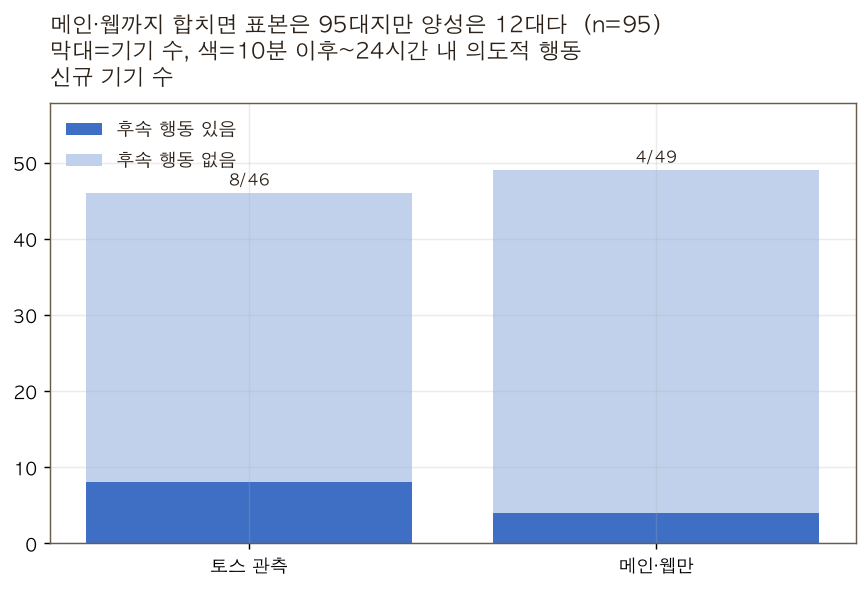

In [3]:
channel = d.groupby('channel_segment', as_index=False).agg(
    devices=('device_label', 'size'),
    later_active_devices=('later_active', 'sum'),
    later_new_area_devices=('later_new_area', 'sum'),
    later_quest_social_devices=('later_quest_social', 'sum'),
    later_fishing_sea_devices=('later_fishing_sea', 'sum'),
    later_nature_devices=('later_nature', 'sum'),
    early_action_events=('early_actions', 'sum'),
    later_action_events=('later_actions', 'sum'),
)
for col in ['later_active_devices', 'later_new_area_devices', 'later_quest_social_devices', 'later_fishing_sea_devices', 'later_nature_devices']:
    channel[col.replace('_devices', '_rate')] = channel[col] / channel.devices
channel.to_csv(OUT / 'channel_summary.csv', index=False)
display(channel)

plot = channel.sort_values('devices')
fig, ax = R.new(
    '메인·웹까지 합치면 표본은 95대지만 양성은 12대다',
    len(d),
    sub='막대=기기 수, 색=10분 이후~24시간 내 의도적 행동',
    ylab='신규 기기 수',
    figsize=(8, 4.4),
)
x = range(len(plot))
inactive = plot.devices - plot.later_active_devices
ax.bar(x, plot.later_active_devices, color=R.PALETTE[1], label='후속 행동 있음')
ax.bar(x, inactive, bottom=plot.later_active_devices, color=R.tint(R.PALETTE[1], .68), label='후속 행동 없음')
ax.set_xticks(list(x), plot.channel_segment)
for i, row in enumerate(plot.itertuples()):
    ax.text(i, row.devices + 1, f"{int(row.later_active_devices)}/{int(row.devices)}", ha='center', fontsize=9)
ax.set_ylim(0, max(plot.devices) * 1.18)
ax.legend(frameon=False)
chart_channel = R.save(fig, ax, 'g3_all_channel_later_active_by_channel')
print(R.check(chart_channel))
display(R.show(chart_channel))


## 4. 라벨 후보별 양성 수

후속 행동을 `새 영역`, `퀘스트·교류`, `낚시·바다`, `자연·채집`으로 나눈다. 후보끼리는 겹친다.

,라벨 후보,양성 기기,전체 기기,양성률,95% 하한,95% 상한,modeling_readiness_flag
0,후속 의도적 행동,12,95,0.126316,0.073756,0.207923,baseline_possible
1,새 영역 첫 도달,9,95,0.094737,0.050644,0.170332,positive<10
2,퀘스트·교류,9,95,0.094737,0.050644,0.170332,positive<10
3,낚시·바다,8,95,0.084211,0.043288,0.157454,positive<10
4,자연·채집,7,95,0.073684,0.036149,0.144358,positive<10


g3_all_channel_later_target_summary.png  1080x631px


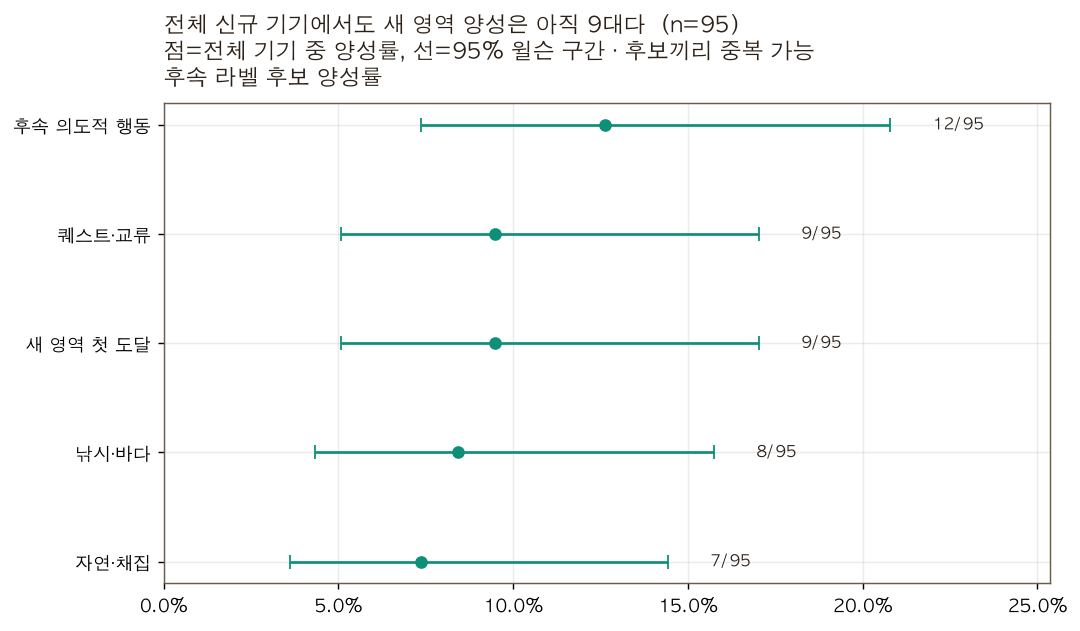

In [4]:
target_rows = [
    ('후속 의도적 행동', 'later_active'),
    ('새 영역 첫 도달', 'later_new_area'),
    ('퀘스트·교류', 'later_quest_social'),
    ('낚시·바다', 'later_fishing_sea'),
    ('자연·채집', 'later_nature'),
]
targets = pd.DataFrame([
    {'라벨 후보': label, '양성 기기': int(d[col].sum()), '전체 기기': len(d), '양성률': float(d[col].mean())}
    for label, col in target_rows
])
targets[['95% 하한', '95% 상한']] = [wilson(k, len(d)) for k in targets['양성 기기']]
targets['modeling_readiness_flag'] = np.where(targets['양성 기기'] < 10, 'positive<10', 'baseline_possible')
targets.to_csv(OUT / 'later_target_summary.csv', index=False)
display(targets)

plot = targets.sort_values('양성 기기')
fig, ax = R.new(
    '전체 신규 기기에서도 새 영역 양성은 아직 9대다',
    len(d),
    sub='점=전체 기기 중 양성률, 선=95% 윌슨 구간 · 후보끼리 중복 가능',
    ylab='후속 라벨 후보 양성률',
    figsize=(8.8, 4.8),
)
y = range(len(plot))
ax.errorbar(
    plot['양성률'],
    list(y),
    xerr=[plot['양성률'] - plot['95% 하한'], plot['95% 상한'] - plot['양성률']],
    fmt='o',
    color=R.PALETTE[2],
    capsize=4,
)
ax.set_yticks(list(y), plot['라벨 후보'])
ax.set_xlim(0, max(plot['95% 상한']) * 1.22)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, (_, row) in enumerate(plot.iterrows()):
    ax.text(row['95% 상한'] + 0.012, i, f"{int(row['양성 기기'])}/{len(d)}", va='center', fontsize=9)
chart_targets = R.save(fig, ax, 'g3_all_channel_later_target_summary', zero_base=False)
print(R.check(chart_targets))
display(R.show(chart_targets))


## 5. 초반 행동량별로 보면

메인·웹만 신규 기기 49대 중 46대가 첫 10분 의도적 행동 0회다. 토스 관측 쪽은 초반 6회 이상이 17대라 행동 꼬리가 훨씬 두껍다. 이 차이는 유입 채널 효과가 아니라 표본 구성 차이로만 읽는다.

,channel_segment,early_action_segment,devices,later_active_devices,later_new_area_devices,later_active_rate,later_new_area_rate
0,메인·웹만,0회,46,2,2,0.043478,0.043478
1,메인·웹만,1~5회,2,1,1,0.5,0.5
2,메인·웹만,6회 이상,1,1,0,1.0,0.0
3,토스 관측,0회,22,2,2,0.090909,0.090909
4,토스 관측,1~5회,7,0,0,0.0,0.0
5,토스 관측,6회 이상,17,6,4,0.352941,0.235294


g3_all_channel_early_action_mix.png  969x611px


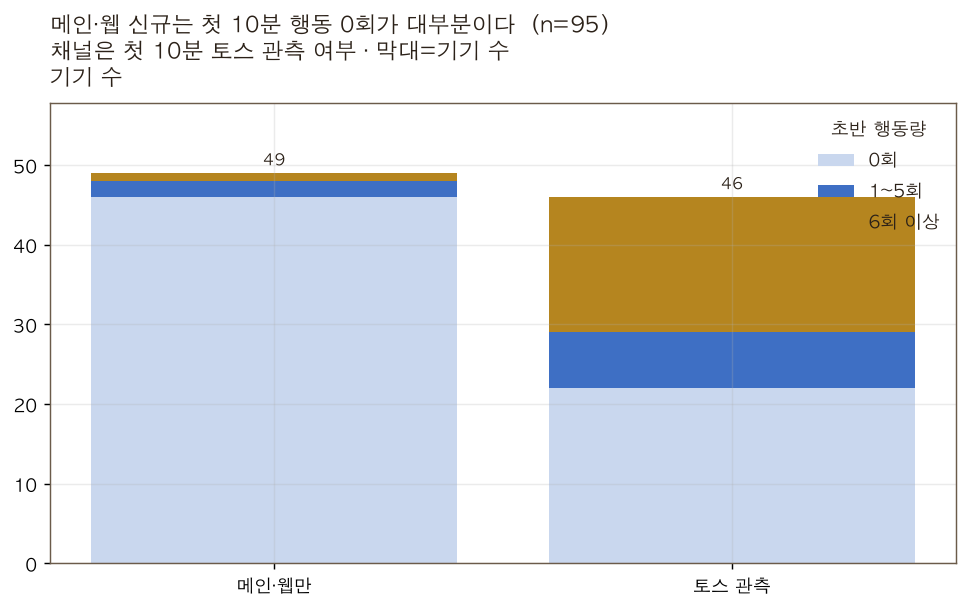

In [5]:
early = d.groupby(['channel_segment', 'early_action_segment'], as_index=False).agg(
    devices=('device_label', 'size'),
    later_active_devices=('later_active', 'sum'),
    later_new_area_devices=('later_new_area', 'sum'),
)
early['later_active_rate'] = early.later_active_devices / early.devices
early['later_new_area_rate'] = early.later_new_area_devices / early.devices
early.to_csv(OUT / 'early_action_by_channel.csv', index=False)
display(early)

fig, ax = R.new(
    '메인·웹 신규는 첫 10분 행동 0회가 대부분이다',
    len(d),
    sub='채널은 첫 10분 토스 관측 여부 · 막대=기기 수',
    ylab='기기 수',
    figsize=(9, 4.6),
)
pivot = early.pivot(index='channel_segment', columns='early_action_segment', values='devices').fillna(0)
pivot = pivot.reindex(columns=['0회', '1~5회', '6회 이상'], fill_value=0)
bottom = np.zeros(len(pivot))
x = range(len(pivot))
for color, col in zip([R.tint(R.PALETTE[1], .72), R.PALETTE[1], R.PALETTE[3]], pivot.columns):
    ax.bar(x, pivot[col], bottom=bottom, color=color, label=col)
    bottom += pivot[col].to_numpy()
ax.set_xticks(list(x), pivot.index)
for i, total in enumerate(bottom):
    ax.text(i, total + 1, str(int(total)), ha='center', fontsize=9)
ax.set_ylim(0, max(bottom) * 1.18)
ax.legend(frameon=False, title='초반 행동량')
chart_early = R.save(fig, ax, 'g3_all_channel_early_action_mix')
print(R.check(chart_early))
display(R.show(chart_early))


## 6. 새 영역 라벨을 다시 쪼개기

전체 신규 기기에서도 `새 영역 첫 도달`은 9대다. 새 영역별로 보면 낚시·바다가 4대, 제작·집이 3대, 고급 콘텐츠가 2대, 퀘스트·교류가 1대다.

,새 영역 후보,도달 기기,전체 기기,도달률,95% 하한,95% 상한
0,자연·채집,0,95,0.000000,0.000000,0.038866
1,낚시·바다,5,95,0.052632,0.022688,0.117350
2,퀘스트·교류,3,95,0.031579,0.010797,0.088772
3,제작·집,3,95,0.031579,0.010797,0.088772
4,고급 콘텐츠,2,95,0.021053,0.005792,0.073543


g3_all_channel_new_area_targets.png  1021x611px


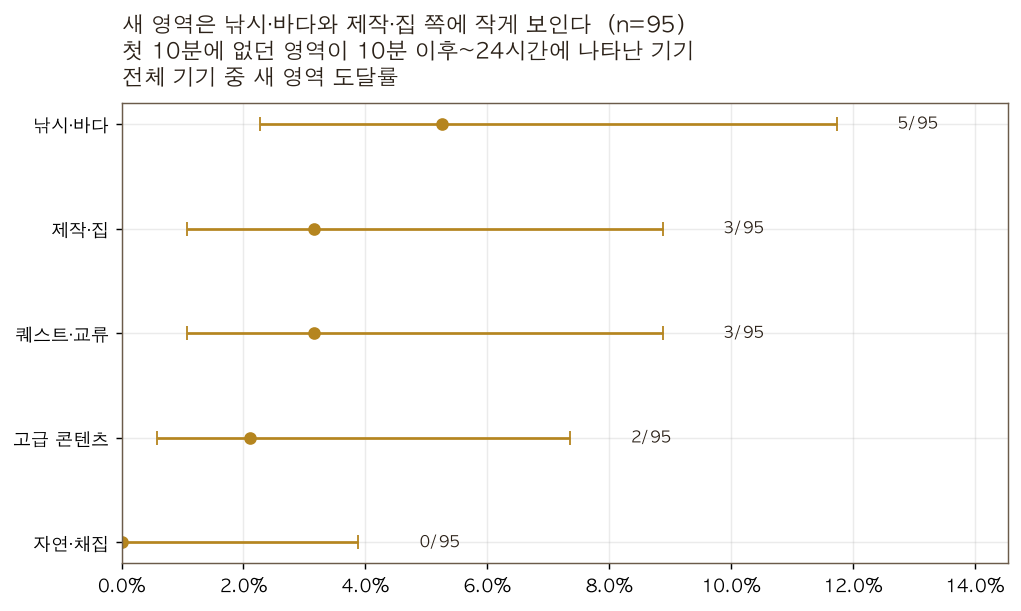

In [6]:
new_cols = [
    ('자연·채집', 'later_new_nature_events'),
    ('낚시·바다', 'later_new_fishing_sea_events'),
    ('퀘스트·교류', 'later_new_quest_social_events'),
    ('제작·집', 'later_new_craft_home_events'),
    ('고급 콘텐츠', 'later_new_advanced_events'),
]
new_area = pd.DataFrame([
    {'새 영역 후보': label, '도달 기기': int((d[col] > 0).sum()), '전체 기기': len(d), '도달률': float((d[col] > 0).mean())}
    for label, col in new_cols
])
new_area[['95% 하한', '95% 상한']] = [wilson(k, len(d)) for k in new_area['도달 기기']]
new_area.to_csv(OUT / 'new_area_target_summary.csv', index=False)
display(new_area)

plot = new_area.sort_values('도달 기기')
fig, ax = R.new(
    '새 영역은 낚시·바다와 제작·집 쪽에 작게 보인다',
    len(d),
    sub='첫 10분에 없던 영역이 10분 이후~24시간에 나타난 기기',
    ylab='전체 기기 중 새 영역 도달률',
    figsize=(8.8, 4.6),
)
y = range(len(plot))
ax.errorbar(
    plot['도달률'],
    list(y),
    xerr=[plot['도달률'] - plot['95% 하한'], plot['95% 상한'] - plot['도달률']],
    fmt='o',
    color=R.PALETTE[3],
    capsize=4,
)
ax.set_yticks(list(y), plot['새 영역 후보'])
ax.set_xlim(0, max(plot['95% 상한']) * 1.24)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, (_, row) in enumerate(plot.iterrows()):
    ax.text(row['95% 상한'] + 0.01, i, f"{int(row['도달 기기'])}/{len(d)}", va='center', fontsize=9)
chart_new = R.save(fig, ax, 'g3_all_channel_new_area_targets', zero_base=False)
print(R.check(chart_new))
display(R.show(chart_new))


## 7. 그래서 크기가 얼마나 되나

토스만 보던 46대에서 전체 신규 95대로 표본은 약 두 배가 됐다. 후속 행동 양성은 8대에서 12대로 늘었고, 새 영역 양성은 6대에서 9대로 늘었다. 늘긴 했지만 모델 학습에는 아직 모자라다. 특히 메인·웹만 49대는 첫 10분 행동 0회가 46대라, 초반 행동 피처로 세밀한 예측을 하기는 어렵다.

지금 이 데이터로 할 수 있는 일은 `새 영역 첫 도달`을 다음 라벨 후보로 남기고, 시설 확장 이후 같은 표를 다시 쌓는 것이다. 바로 모델을 만들기보다 post-change 코호트가 붙은 뒤 100대 이상, 새 영역 양성 20대 안팎을 기다리는 쪽이 정석이다.

## 8. 이 숫자로 말할 수 없는 것

- 토스와 메인·웹의 우열이 아니다. 유입 날짜, 기기, 플랫폼 계측, 첫 10분 이벤트 밀도가 섞여 있다.
- A/B 효과가 아니다. 베타 테스터 표식만 제외했고, arm별 비교는 하지 않았다.
- D1/D7 리텐션이 아니다. 10분 이후~24시간 내 의도적 행동이라는 짧은 대리 라벨이다.
- 시설 확장 후 효과가 아니다. 이 표는 2026-09-12까지의 완전 export 기준이고, 9/14 변경 이후 코호트는 아직 없다.

In [7]:
assumptions = {
    'analysis': 'g3-all-channel-later-target-label-eda',
    'date': '2026-09-15',
    'source': 'BigQuery GA4 daily export, first-observed devices 2026-09-04 through 2026-09-11 KST',
    'gate': 'G3 all-channel label target EDA',
    'result': 'larger_sample_but_model_training_still_deferred',
    'checks': {
        'device_rows': int(len(d)),
        'later_active_devices': int(d.later_active.sum()),
        'later_new_area_devices': int(d.later_new_area.sum()),
        'feature_boundary_violations': int(d.feature_boundary_violations.sum()),
        'label_boundary_violations': int(d.label_boundary_violations.sum()),
    },
    'exclusions': ['marked beta tester devices: beta_A/beta_B'],
    'not_analyzed': ['A/B effect', 'causal channel comparison', 'D1/D7 retention'],
    'candidate_next_label': {
        'name': 'later_new_area',
        'positive_devices': int(d.later_new_area.sum()),
        'status': 'candidate_only',
    },
}
(OUT / 'assumptions.json').write_text(json.dumps(assumptions, ensure_ascii=False, indent=2), encoding='utf-8')
display(Markdown('```json\n' + json.dumps(assumptions, ensure_ascii=False, indent=2) + '\n```'))


```json
{
  "analysis": "g3-all-channel-later-target-label-eda",
  "date": "2026-09-15",
  "source": "BigQuery GA4 daily export, first-observed devices 2026-09-04 through 2026-09-11 KST",
  "gate": "G3 all-channel label target EDA",
  "result": "larger_sample_but_model_training_still_deferred",
  "checks": {
    "device_rows": 95,
    "later_active_devices": 12,
    "later_new_area_devices": 9,
    "feature_boundary_violations": 0,
    "label_boundary_violations": 0
  },
  "exclusions": [
    "marked beta tester devices: beta_A/beta_B"
  ],
  "not_analyzed": [
    "A/B effect",
    "causal channel comparison",
    "D1/D7 retention"
  ],
  "candidate_next_label": {
    "name": "later_new_area",
    "positive_devices": 9,
    "status": "candidate_only"
  }
}
```

## 9. 판정

**G3 전체 채널 라벨 후보 EDA 통과, 모델링 보류.** 메인·웹까지 합치면 표본은 커지지만 양성 수가 아직 작다. 다음에 볼 만한 기준 라벨은 `새 영역 첫 도달`이고, 시설 확장 이후 코호트를 따로 쌓아 같은 표를 재실행한다. 여기서 멈춘다.